# 03: Baselines across the ablation ladder

Notebook 02 established something that changes how this study has to be run: **PaySim's fraud label is recoverable by three boolean clauses** 

```
type ∈ {TRANSFER, CASH_OUT}  AND  amount == oldbalanceOrg  AND  newbalanceOrig == 0
```

 at precision 0.9999 and recall 0.9770. PaySim's fraud agents follow a deterministic script, and that script survives into the data.

A model handed the balance columns can rediscover that script, and then it is reciting the simulator rather than detecting fraud. So the question this notebook answers is not "which learner wins" but **where on the ablation ladder does this stop being a lookup and start being a learning problem?**  because a cost-sensitive comparison run on a solved task measures nothing.

| rung | drops | rationale |
|---|---|---|
| `full` |  | everything, as the prior work used it |
| `no_error_features` | 2 | the derived balance errors |
| `no_origin_balance` | 6 | **all** origin-side state  a tree reconstructs the rule from the raw columns, so dropping only the derived features is not enough |
| `transaction_only` | 10 | no balance state at all: amount, type, time |

The rungs are cumulative and strictly nested, so results read as a progression.

Each rung fits the **unweighted** model, which serves configs A (t=0.5), B (ROC-optimal) and C (NER-optimal): thresholding is post-hoc on a probability vector, so seven configurations cost four fits per learner, not seven.

In [1]:
import sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import analysis as A
from momo_fraud import constants as C
from momo_fraud import data as D
from momo_fraud import evaluate as E
from momo_fraud import experiment as X
from momo_fraud import risk as RK
from momo_fraud import splits as S
from momo_fraud import viz
from momo_fraud.features import FEATURE_SETS, FeatureBuilder, columns_for

viz.apply_house_style()

SEEDS = [C.RANDOM_SEED]
R = C.R_DEFAULT

df = D.load()
y = df[C.TARGET].to_numpy()
print(f"{len(df):,} transactions | R = {R:.2f} | lambda = {RK.bayes_threshold(R):.6f}")

6,362,620 transactions | R = 773.70 | lambda = 0.001291


## The score to beat

Any model on this dataset should be read against the boolean rule, not against the published literature. A rule with no parameters and no training already outperforms every PaySim result we found in the review.

In [2]:
rules = A.rule_recoverability(df)
best_rule = rules.iloc[-1]
print(f"{best_rule['rule']}\n  precision {best_rule['precision']:.4%}  "
      f"recall {best_rule['recall']:.4%}  ({best_rule['n_flagged']:,} alerts)\n")
print("Published PR-AUC on this same dataset (Thar & Wai 2025):")
for name, value in C.THAR_WAI_PR_AUC.items():
    print(f"  {name:22s} {value:.4f}")

risky type AND drained AND emptied
  precision 99.9875%  recall 97.6988%  (8,025 alerts)

Published PR-AUC on this same dataset (Thar & Wai 2025):
  logistic_regression    0.7120
  random_forest          0.8905
  xgboost                0.9160
  hmm                    0.7050
  hybrid_hmm_xgboost     0.9689


In [3]:
split = S.stratified_split(y)
builder = FeatureBuilder().fit(df.iloc[split.train])

X_all = builder.transform(df)
severity_all = builder.severity_of(df)

labels = {k: y[getattr(split, k)] for k in ("train", "val", "test")}
severity = {k: severity_all[getattr(split, k)] for k in ("train", "val", "test")}

for name, size in split.sizes().items():
    print(f"  {name:6s} {size:>9,}  fraud {int(labels[name].sum()):>5,}  "
          f"prevalence {labels[name].mean():.5%}")

  train  4,453,834  fraud 5,749  prevalence 0.12908%
  val      954,392  fraud 1,232  prevalence 0.12909%
  test     954,394  fraud 1,232  prevalence 0.12909%


## Fit every rung

Four rungs x four learners. The **best achievable NER** column is the one that decides where the experiment can live: NER is the fraction of do-nothing risk that remains after the best possible threshold, so a rung where it is already near zero has no headroom for any cost-sensitive method to demonstrate anything.

In [4]:
start = time.perf_counter()
all_results = []

for feature_set in FEATURE_SETS:
    cols = columns_for(feature_set, list(X_all.columns))
    parts = {k: X_all.iloc[getattr(split, k)][cols] for k in ("train", "val", "test")}
    print(f"\n--- {feature_set} ({len(cols)} features) ---")

    all_results.append(X.run_grid(
        parts["train"], labels["train"], parts["val"], labels["val"],
        parts["test"], labels["test"],
        variants=["unweighted"], seeds=SEEDS, r=R,
        severity=severity, feature_set=feature_set,
    ))

results = pd.concat(all_results, ignore_index=True)
E.save_results(results.to_dict("records"), "03_baselines_all_rungs")
print(f"\ntotal {time.perf_counter() - start:.0f}s")


--- full (20 features) ---
[1/4] logistic_regression / unweighted / seed 42 …

   12.4s  test PR-AUC 0.8160


[2/4] decision_tree / unweighted / seed 42 …

  117.6s  test PR-AUC 0.9928


[3/4] random_forest / unweighted / seed 42 …

...

[3/4] random_forest / unweighted / seed 42 …

  175.1s  test PR-AUC 0.5082


[4/4] xgboost / unweighted / seed 42 …

  112.2s  test PR-AUC 0.5697



total 1971s


In [5]:
ladder = (results.query("split == 'test' and config == 'C'")
          .pivot_table(index="feature_set", columns="learner", values=["pr_auc", "ner"])
          .reindex(list(FEATURE_SETS)))

headroom = (results.query("split == 'test' and config == 'C'")
            .groupby("feature_set")["ner"].min()
            .reindex(list(FEATURE_SETS))
            .rename("best_ner"))
E.save_results(headroom.reset_index().to_dict("records"), "03_ladder_headroom")

print("Best achievable NER per rung (0 = solved, 1 = no better than doing nothing):")
for rung, value in headroom.items():
    bar = "#" * max(int(value * 50), 1)
    print(f"  {rung:22s} {value:.4f}  {bar}")
ladder.round(4)

Best achievable NER per rung (0 = solved, 1 = no better than doing nothing):
  full                   0.0041  #
  no_error_features      0.0094  #
  no_origin_balance      0.1314  ######
  transaction_only       0.1931  #########


ner                                            \
learner           decision_tree logistic_regression random_forest xgboost   
feature_set                                                                 
full                     0.0057              0.0599        0.0057  0.0041   
no_error_features        0.1505              0.1035        0.0179  0.0094   
no_origin_balance        0.1527              0.2499        0.1324  0.1314   
transaction_only         0.2312              0.3906        0.1959  0.1931   

                         pr_auc                                            
learner           decision_tree logistic_regression random_forest xgboost  
feature_set                                                                
full                     0.9928              0.8160        0.9963  0.9977  
no_error_features        0.7608              0.7672        0.9149  0.9676  
no_origin_balance        0.7297              0.5040        0.7967  0.8173  
transaction_only         0.3822              0.0784        0.5082  0.5697

## Where the experiment can live

The rung chosen below is the one where enough risk survives that a cost-sensitive method has something to act on. It is recorded to `results/` and read by notebooks 04–06, so the choice is made once, here, on evidence  rather than assumed.

In [6]:
#: Below this, the task is effectively solved and every configuration lands in
#: the same sliver of remaining risk -- differences would be noise, not effect.
HEADROOM_FLOOR = 0.05

viable = headroom[headroom >= HEADROOM_FLOOR]
if viable.empty:
    chosen = headroom.idxmax()
    note = "no rung clears the floor; taking the one with the most headroom"
else:
    chosen = viable.index[0]   # the least-ablated rung that still has headroom
    note = f"least-ablated rung with NER >= {HEADROOM_FLOOR}"

decision = {
    "experimental_rung": chosen,
    "best_ner_at_rung": float(headroom[chosen]),
    "headroom_floor": HEADROOM_FLOOR,
    "rationale": note,
    "features_dropped": FEATURE_SETS[chosen],
    "rule_precision": float(best_rule["precision"]),
    "rule_recall": float(best_rule["recall"]),
}
E.save_json(decision, "03_experimental_rung")

print(f"Experimental rung: {chosen}  (best NER {headroom[chosen]:.4f})")
print(f"  {note}")
print(f"  drops: {FEATURE_SETS[chosen] or 'nothing'}")
print("\nThe full-feature results remain in the report as evidence of the artifact ")
print("they measure the simulator, not fraud detection.")

Experimental rung: no_origin_balance  (best NER 0.1314)
  least-ablated rung with NER >= 0.05
  drops: ['errorBalanceDest', 'errorBalanceOrig', 'newbalanceOrig', 'oldbalanceOrg', 'origZeroAfter', 'origZeroBefore']

The full-feature results remain in the report as evidence of the artifact 
they measure the simulator, not fraud detection.


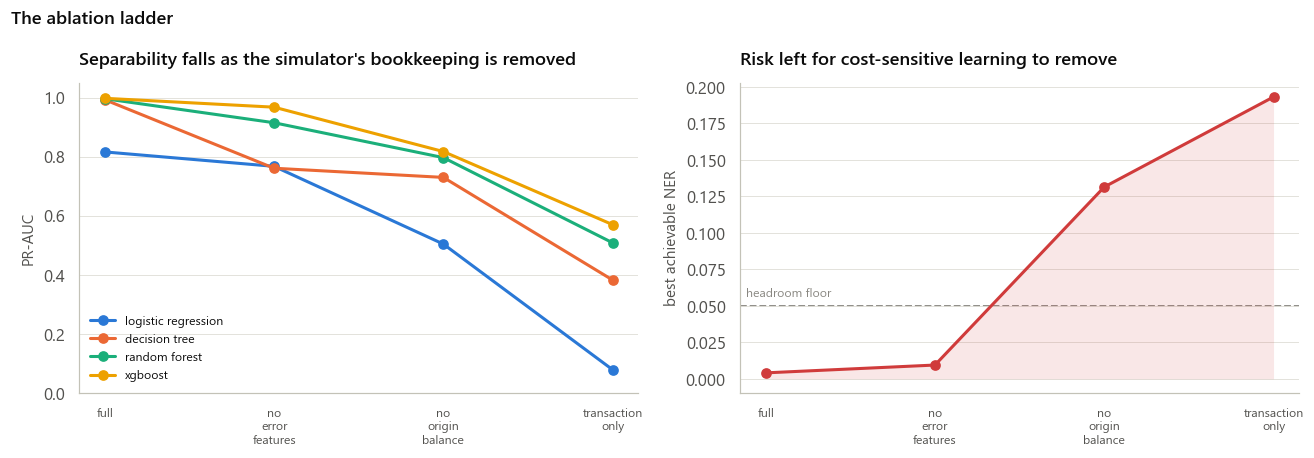

In [7]:
fig, (ax_pr, ax_ner) = plt.subplots(1, 2, figsize=(12, 4.2))
rungs = list(FEATURE_SETS)
test = results.query("split == 'test' and config == 'C'")

for learner in C.LEARNERS:
    row = test[test["learner"] == learner].set_index("feature_set").reindex(rungs)
    ax_pr.plot(range(len(rungs)), row["pr_auc"], marker="o",
               color=viz.LEARNER_COLORS[learner], label=learner.replace("_", " "))

ax_pr.set(title="Separability falls as the simulator's bookkeeping is removed",
          ylabel="PR-AUC", ylim=(0, 1.05))
ax_pr.legend(loc="lower left", fontsize=8)

ax_ner.plot(range(len(rungs)), headroom.values, marker="o",
            color=viz.STATUS["critical"])
ax_ner.fill_between(range(len(rungs)), headroom.values, alpha=0.12,
                    color=viz.STATUS["critical"])
viz.annotate_reference(ax_ner, HEADROOM_FLOOR, "headroom floor", axis="y", side="left")
ax_ner.set(title="Risk left for cost-sensitive learning to remove",
           ylabel="best achievable NER")

for ax in (ax_pr, ax_ner):
    ax.set_xticks(range(len(rungs)))
    ax.set_xticklabels([r.replace("_", "\n") for r in rungs], fontsize=8)
    viz.despine(ax)

fig.suptitle("The ablation ladder", x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "03_ablation_ladder")
plt.show()

## Pipeline check against published results

Deliberately **one-sided**. Falling well below a published number on identical data points at a bug. Landing above it does not: this study engineers balance features the prior work did not, so outperforming it is expected. What does warrant suspicion is near-perfection, which at 0.129% prevalence usually means something leaked.

The sharper check is the progression: as rungs strip the artifact away, results should converge toward the published values  and at `no_error_features` they land almost exactly on them, which suggests that is the feature set the published work effectively used.

Deeper rungs are marked **not comparable**. There we have deliberately removed information the published study had, so falling below it is the ablation working, not a defect.

In [8]:
checks = []
for feature_set in FEATURE_SETS:
    # Only rungs whose features the published work could plausibly have used are
    # judged against it. Below those we removed information on purpose, so
    # scoring lower is the experiment working -- not a bug to chase.
    check = X.benchmark_check(
        results.query("feature_set == @feature_set"),
        comparable=(feature_set in X.COMPARABLE_RUNGS),
    )
    check.insert(0, "feature_set", feature_set)
    checks.append(check)

benchmarks = pd.concat(checks, ignore_index=True)
E.save_results(benchmarks.to_dict("records"), "03_benchmark_check")
benchmarks.round(4)

,feature_set,learner,observed_pr_auc,thar_wai_pr_auc,difference,comparable,verdict,passes
0,full,logistic_regression,0.8160,0.7120,0.1040,True,above published (expected: richer features),True
1,full,random_forest,0.9963,0.8905,0.1058,True,SUSPICIOUSLY HIGH - investigate for leakage,False
2,full,xgboost,0.9977,0.9160,0.0817,True,SUSPICIOUSLY HIGH - investigate for leakage,False
3,no_error_features,logistic_regression,0.7672,0.7120,0.0552,True,above published (expected: richer features),True
4,no_error_features,random_forest,0.9149,0.8905,0.0244,True,above published (expected: richer features),True
5,no_error_features,xgboost,0.9676,0.9160,0.0516,True,above published (expected: richer features),True
6,no_origin_balance,logistic_regression,0.5040,0.7120,-0.2080,False,not comparable (features deliberately removed),True
7,no_origin_balance,random_forest,0.7967,0.8905,-0.0938,False,not comparable (features deliberately removed),True
8,no_origin_balance,xgboost,0.8173,0.9160,-0.0987,False,not comparable (features deliberately removed),True
9,transaction_only,logistic_regression,0.0784,0.7120,-0.6336,False,not comparable (features deliberately removed),True


C:\Users\siphe\AppData\Local\Temp\ipykernel_7028\1594198314.py:20: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  fig.tight_layout()
C:\Users\siphe\source\repos\CodeHermez\momo-fraud-supervised-ml\src\momo_fraud\viz.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  fig.savefig(path, **kwargs)


C:\Users\siphe\source\repos\CodeHermez\momo-fraud-supervised-ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


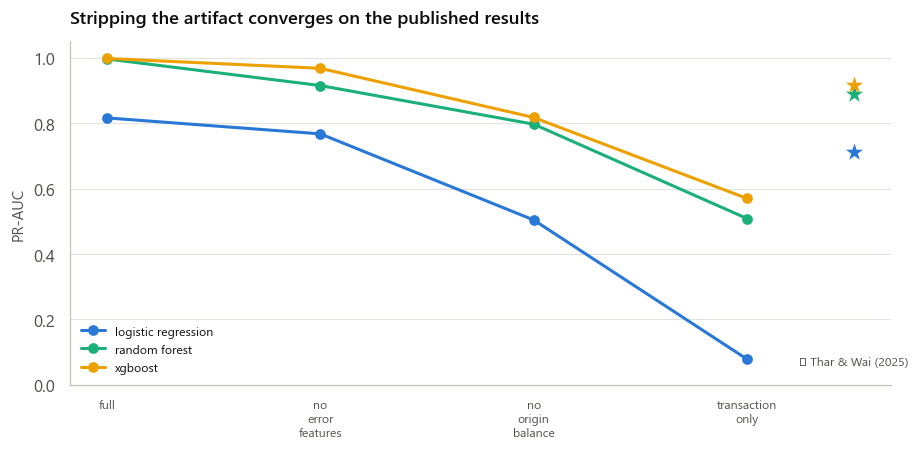

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

for i, learner in enumerate(["logistic_regression", "random_forest", "xgboost"]):
    row = (benchmarks[benchmarks["learner"] == learner]
           .set_index("feature_set").reindex(rungs))
    ax.plot(range(len(rungs)), row["observed_pr_auc"], marker="o",
            color=viz.LEARNER_COLORS[learner], label=learner.replace("_", " "))
    ax.scatter([len(rungs) - 0.5], [C.THAR_WAI_PR_AUC[learner]], marker="*", s=140,
               color=viz.LEARNER_COLORS[learner], zorder=5)

ax.annotate("★ Thar & Wai (2025)", xy=(len(rungs) - 0.5, 0.06),
            ha="center", fontsize=8, color=viz.INK["secondary"])
ax.set(title="Stripping the artifact converges on the published results",
       ylabel="PR-AUC", ylim=(0, 1.05))
ax.set_xticks(range(len(rungs)))
ax.set_xticklabels([r.replace("_", "\n") for r in rungs], fontsize=8)
ax.legend(loc="lower left", fontsize=8)
viz.despine(ax)

fig.tight_layout()
viz.save_figure(fig, "03_benchmark_convergence")
plt.show()

## At the experimental rung

Precision–recall, the three threshold rules, and calibration: all at the rung the experiment will actually use.

PR rather than ROC: at 774 negatives per positive, ROC-AUC is near-insensitive to false positives, which is how the prior work reported 0.92+ while operating where no fraud team could staff the queue.

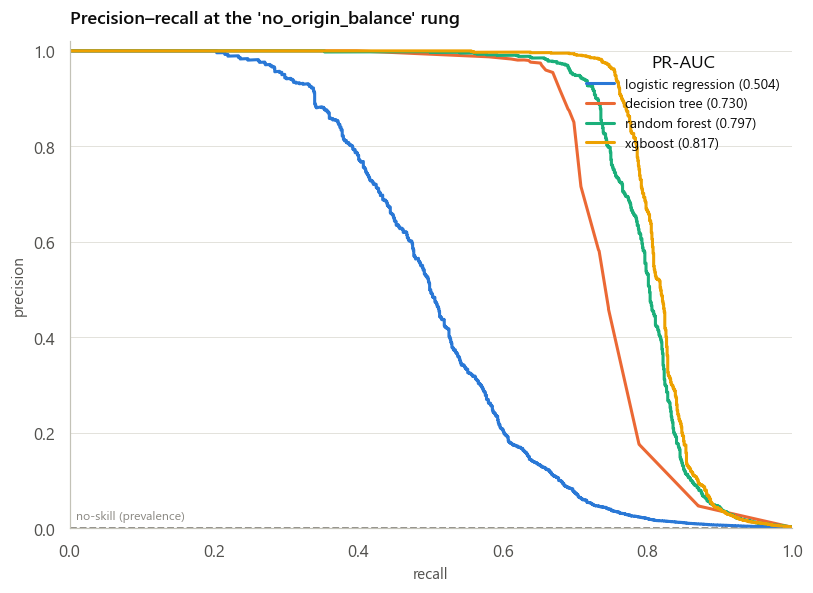

In [10]:
from sklearn.metrics import precision_recall_curve

seed, tag = SEEDS[0], chosen
fig, ax = plt.subplots(figsize=(7.5, 5.5))

for learner in C.LEARNERS:
    cached = E.load_predictions(learner, "unweighted", "test", seed, tag=tag)
    precision, recall, _ = precision_recall_curve(cached["y_true"], cached["score"])
    pr_auc = test.query("learner == @learner and feature_set == @chosen")["pr_auc"].iloc[0]
    ax.plot(recall, precision, color=viz.LEARNER_COLORS[learner],
            label=f"{learner.replace('_', ' ')} ({pr_auc:.3f})")

viz.annotate_reference(ax, labels["test"].mean(), "no-skill (prevalence)",
                       axis="y", side="left")
ax.set(title=f"Precision–recall at the '{chosen}' rung",
       xlabel="recall", ylabel="precision", xlim=(0, 1), ylim=(0, 1.02))
ax.legend(title="PR-AUC", loc="upper right")
viz.despine(ax)

fig.tight_layout()
viz.save_figure(fig, "03_pr_curves")
plt.show()

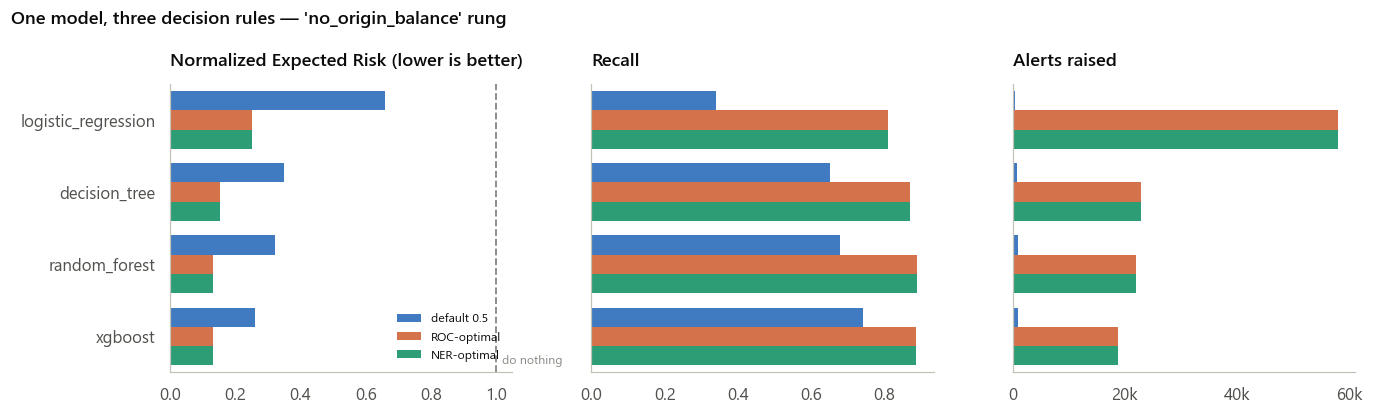

In [11]:
at_rung = results.query("split == 'test' and feature_set == @chosen").copy()
at_rung["rule"] = at_rung["config"].map({"A": "default 0.5", "B": "ROC-optimal",
                                         "C": "NER-optimal"})
rule_order = ["default 0.5", "ROC-optimal", "NER-optimal"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
for ax, (metric, title) in zip(axes, [
    ("ner", "Normalized Expected Risk (lower is better)"),
    ("recall", "Recall"),
    ("n_flagged", "Alerts raised"),
]):
    sns.barplot(at_rung, x=metric, y="learner", hue="rule", hue_order=rule_order,
                palette=viz.CATEGORICAL[:3], ax=ax, legend=(ax is axes[0]))
    ax.set(title=title, xlabel="", ylabel="")
    if metric == "n_flagged":
        ax.xaxis.set_major_formatter(viz.compact_number)
    viz.despine(ax)
    ax.grid(axis="y", visible=False)
    if ax is not axes[0]:
        ax.set_yticklabels([])

axes[0].legend(title="", loc="lower right", fontsize=8)
viz.annotate_reference(axes[0], 1.0, "do nothing", axis="x", below=True)

fig.suptitle(f"One model, three decision rules  '{chosen}' rung", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "03_threshold_rules")
plt.show()

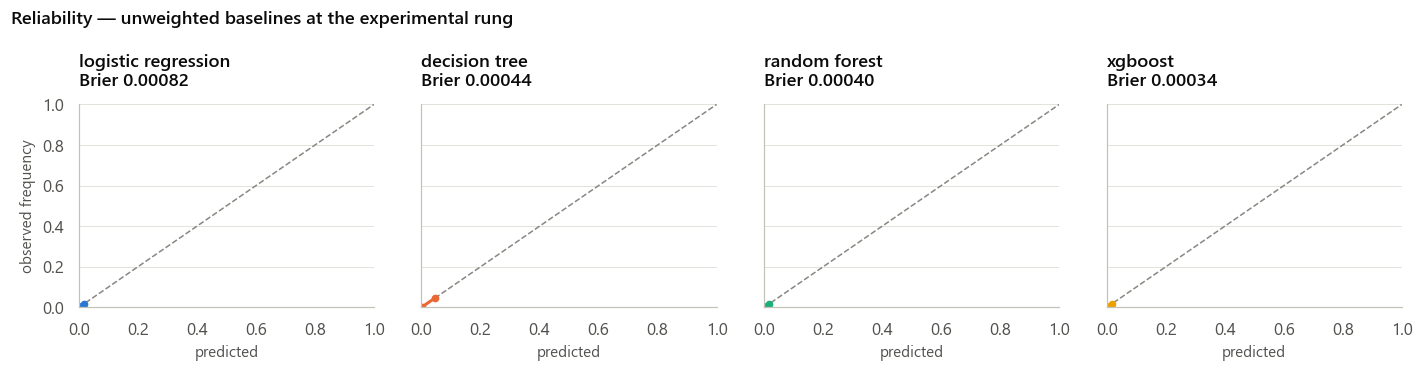

In [12]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, learner in zip(axes, C.LEARNERS):
    cached = E.load_predictions(learner, "unweighted", "test", seed, tag=tag)
    observed, predicted = calibration_curve(cached["y_true"], cached["score"],
                                            n_bins=15, strategy="quantile")
    brier = at_rung.query("learner == @learner and config == 'A'")["brier"].iloc[0]

    ax.plot([0, 1], [0, 1], color=viz.INK["muted"], linestyle="--", linewidth=1)
    ax.plot(predicted, observed, marker="o", markersize=4,
            color=viz.LEARNER_COLORS[learner])
    ax.set(title=f"{learner.replace('_', ' ')}\nBrier {brier:.5f}",
           xlabel="predicted", xlim=(0, 1), ylim=(0, 1))
    viz.despine(ax)

axes[0].set_ylabel("observed frequency")
fig.suptitle("Reliability: unweighted baselines at the experimental rung",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "03_calibration")
plt.show()

In [13]:
print(f"Experimental rung recorded: {chosen}")
print(f"Cached probability vectors for all four rungs (unweighted variant).")
print("\nNext: 04_cost_sensitive.ipynb: the weighted, instance-weighted and RUS")
print("variants at this rung, and the H1 test on whether any of them beat what is")
print("already here.")

Experimental rung recorded: no_origin_balance
Cached probability vectors for all four rungs (unweighted variant).

Next: 04_cost_sensitive.ipynb  the weighted, instance-weighted and RUS
variants at this rung, and the H1 test on whether any of them beat what is
already here.
